In [1]:
import sys
sys.path.append('../src')

In [2]:
from integrand_builder import IntegrandBuilder
from wrapped_eval import WrappedEvaluator
from context_manager import TriangleIntegrandContext, TriangleIntegrandEvaluator
import numpy as np
from symbolica import *
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pyvista as pv
from plot_util import plot_complex_plane
from IPython.display import HTML

In [3]:
ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
e_surf_eval = WrappedEvaluator(N(1)/ib.unsubtracted(), ib.get_args(), "eta_01")
eval = TriangleIntegrandEvaluator(e_surf_eval, ctx)

Compiling evaluator: "eta_01"
Done!


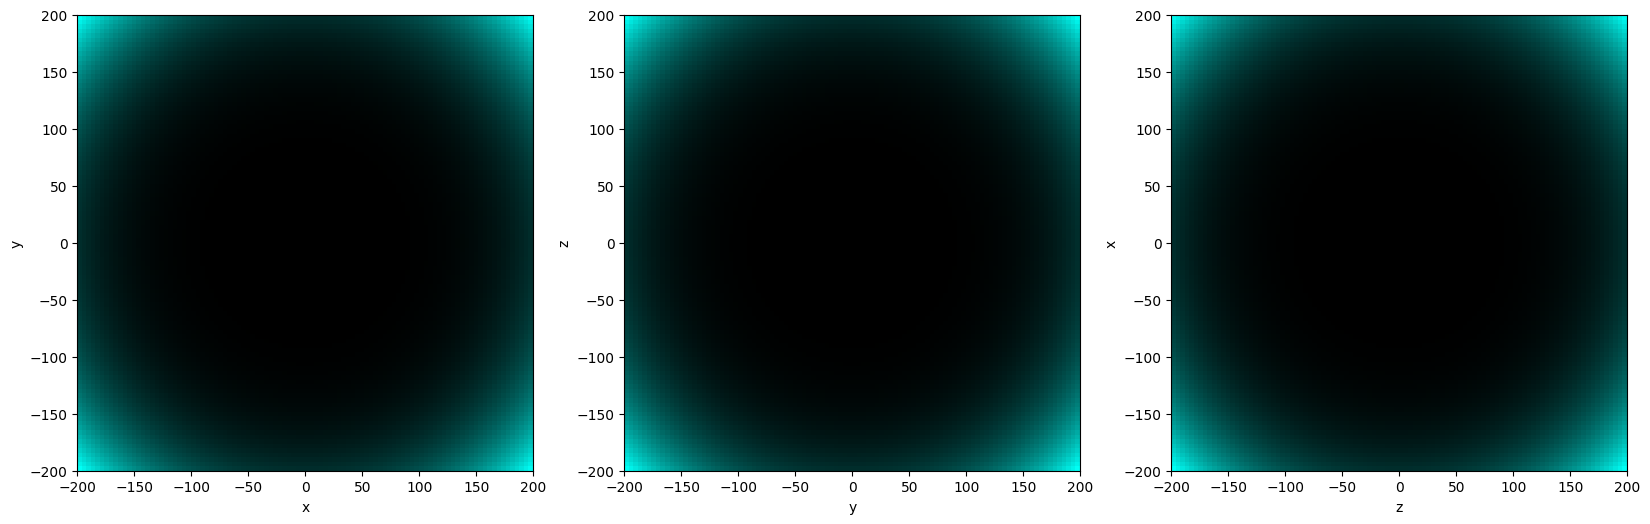

In [4]:
eval.plot_planes((-200,200), (-200,200))

In [5]:
def plot_e_surface(x_lim, y_lim, z_lim, res):
    surf = eval.contour(x_lim, y_lim, z_lim, res)
    
    plotter = pv.Plotter()
    plotter.add_mesh(surf, color="cyan", opacity=0.5, smooth_shading=True)

    q0 = ctx.get_qs()[0]
    q1 = ctx.get_qs()[1]
    q = (q0-q1)/2
    start = (q0+q1)[1:]/2

    arrow = pv.Arrow(start=start, direction=q[1:]/q[0], scale=0.3)
    plotter.add_mesh(arrow, color="red")
    return plotter


In [ ]:
def animate_eta_of_k(k_hat,update_ctx, frames):
    x = np.linspace(-2,2, 300)
    y = np.linspace(-2,2, 300)
    X, Y = np.meshgrid(x, y)

    xs = X + 1j*Y

    # Set up figure
    fig, ax = plt.subplots()

    # Animation function
    def update(frame):
        update_ctx(frame)
        y = 1 / eval.eval(xs[..., None] * k_hat)
        plot_complex_plane(xs, y, ax=ax)
        ax.set_title(f"m = {frame:.2f}")

    # Frames
    return FuncAnimation(fig, update, frames=frames, interval=200)

In [7]:
ctx.set_anomalous_configuration(p2 = 202)
plotter = plot_e_surface((-50,50), (-50,50), (-50,50), 100)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:41401/index.html?ui=P_0x7705e90286e0_0&reconnect=auto" class="pyvi…

In [8]:
ctx.set_anomalous_configuration(p2 = 203)
plotter = plot_e_surface((-50,50), (-50,50), (-50,50), 200)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:41401/index.html?ui=P_0x77062dc438f0_1&reconnect=auto" class="pyvi…

In [9]:
ctx.set_anomalous_configuration(p2 = 170)
plotter = plot_e_surface((-500,500), (-500,500), (-250,750), 100)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:41401/index.html?ui=P_0x7705d296bc50_2&reconnect=auto" class="pyvi…

In [10]:
ctx.set_anomalous_configuration(p2 = 180)
plotter = plot_e_surface((-500,500), (-500,500), (-250,750), 100)
plotter.show_grid()
plotter.show()

Widget(value='<iframe src="http://localhost:41401/index.html?ui=P_0x7705dbe382c0_3&reconnect=auto" class="pyvi…

In [11]:
m_values = 1.2-0.7**np.linspace(0, 6, 30)
ani = animate_eta_of_k(np.array([0,0,1]), set_ctx_masses, m_values)
display(HTML(ani.to_jshtml(default_mode='reflect')))
plt.close()

NameError: name 'set_ctx_masses' is not defined

In [ ]:
set_ctx_masses(0.5)

k_hat = np.array([0,3,4])/5

ctx.origin = [0, 0, 0, 1]
plotter = plot_e_surface((-2,2), (-2,2), (0,4), 100)
plotter.add_mesh(pv.Line(0*k_hat, 2*k_hat))
plotter.show_grid()
plotter.show()

In [ ]:
m_values = 1.2-0.7**np.linspace(0, 6, 30)
ani = animate_eta_of_k(k_hat, set_ctx_masses, m_values)
display(HTML(ani.to_jshtml(default_mode='reflect')))
plt.close()
